/home/kdg/anaconda3/envs/r2c/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1800, 2)


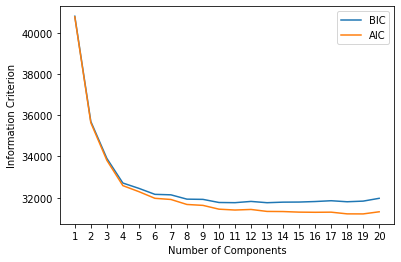

In [1]:
import torch
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Load the 2D essay vector data
data = torch.load('../pt/D3_e2v_2d.pt')
print(data.shape)

# Define range of cluster numbers to test
n_components = np.arange(1, 21)

# Fit Gaussian Mixture Models with different numbers of components
models = [GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(data)
          for n in n_components]

# Calculate BIC and AIC for each model
bic_scores = [m.bic(data) for m in models]
aic_scores = [m.aic(data) for m in models]

# Plot BIC and AIC curves
plt.plot(n_components, bic_scores, label='BIC')
plt.plot(n_components, aic_scores, label='AIC')
plt.legend(loc='best')
plt.xticks(range(1, 21))
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.show()